## Подготовка данных и предобработка

В этом разделе мы загружаем датасет с результатами кластеризации пациентов.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix

df = pd.read_csv('patient_segmentation_dataset_with_clusters.xls')

X = df.drop(['PatientID', 'Last_Visit_Date', 'cluster_kmeans', 'cluster_dbscan', 'cluster_agg'], axis=1)
y = df['cluster_kmeans']

X = X.fillna('Unknown')
for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Обучение и оценка моделей

Мы сравниваем три различных алгоритма классификации, чтобы определить, какой из них лучше всего предсказывает принадлежность пациента к кластеру.

In [12]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(random_state=42),
    "SVC": SVC()
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results[name] = accuracy_score(y_test, y_pred)
    print(f"\nModel: {name}\n", classification_report(y_test, y_pred))


Model: LogisticRegression
               precision    recall  f1-score   support

           0       0.99      1.00      0.99        66
           1       0.97      0.98      0.98        65
           2       0.97      0.95      0.96        37
           3       1.00      0.99      1.00       104
           4       0.95      0.95      0.95        41
           5       1.00      1.00      1.00        87

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.99      0.98      0.98       400


Model: RandomForest
               precision    recall  f1-score   support

           0       0.89      0.88      0.89        66
           1       0.90      0.88      0.89        65
           2       0.95      0.95      0.95        37
           3       0.99      0.96      0.98       104
           4       0.83      0.98      0.90        41
           5       0.98      0.97      0.97        87

    accuracy               

Судя по отчетам классификации Logistic Regression показала наилучший результат с точностью 98%.

## Создание графиков

Наглядно сравним точность наших моделей

C:\Users\sondi\AppData\Local\Temp\ipykernel_24860\1685888435.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(results.keys()), y=list(results.values()), palette=colors)


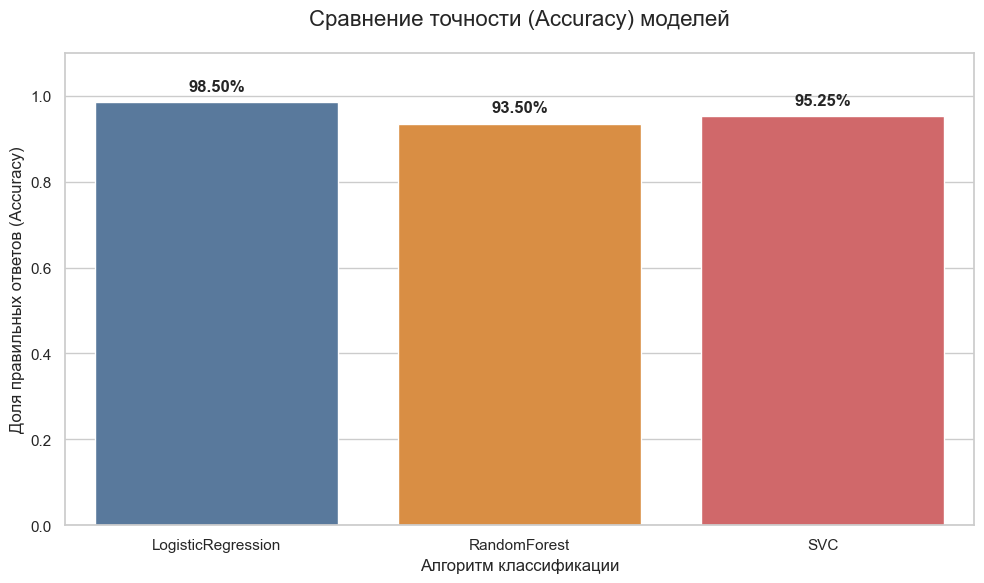

In [13]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
model_names = list(results.keys())
model_acc = list(results.values())
colors = ['#4e79a7', '#f28e2b', '#e15759']

ax = sns.barplot(
    x=model_names, 
    y=model_acc, 
    palette=colors, 
    hue=model_names, 
    legend=False
)

plt.title('Сравнение точности (Accuracy) моделей', fontsize=16, pad=20)
plt.ylabel('Доля правильных ответов (Accuracy)', fontsize=12)
plt.xlabel('Алгоритм классификации', fontsize=12)
plt.ylim(0, 1.1)

for i, v in enumerate(model_acc):
    ax.text(i, v + 0.02, f"{v:.2%}", ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Создадим наглядный пример ошибок кластеров на лучшей модели

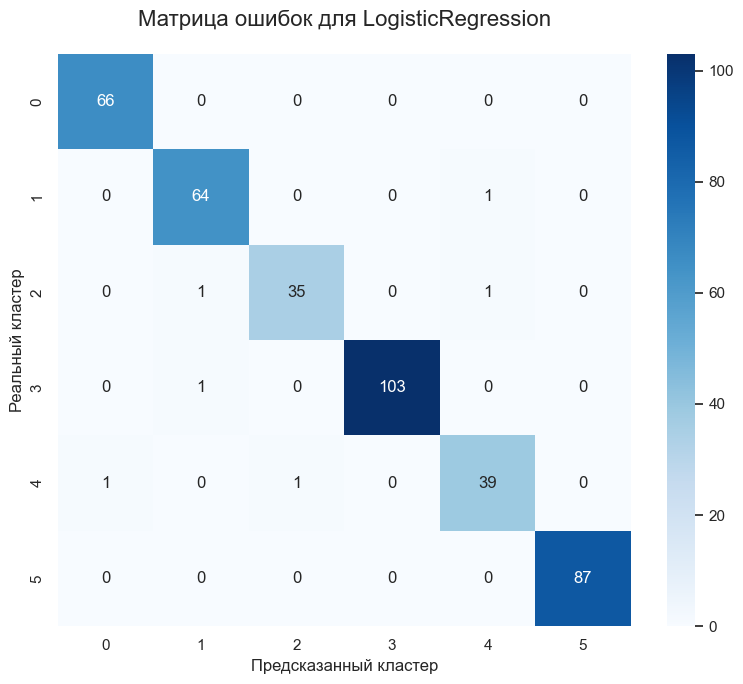

In [14]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y.unique()), 
            yticklabels=sorted(y.unique()))

plt.title(f'Матрица ошибок для {best_model_name}', fontsize=16, pad=20)
plt.xlabel('Предсказанный кластер', fontsize=12)
plt.ylabel('Реальный кластер', fontsize=12)
plt.tight_layout()
plt.show()

### Сохранение лучшей модели

In [5]:
best_model_name = max(results, key=results.get)
joblib.dump(models[best_model_name], 'classification_model.kpl')
print(f"Saved best model: {best_model_name}")

Saved best model: LogisticRegression


Модель сохранена в файл classification_model.kpl